# Final Model Comparison

This notebook compares all evaluated guardrail models.

**Models Evaluated:**
1. Qwen3Guard-Gen-0.6B (600M params, local)
2. Pipeline Multicapa (5 SLMs, ~1B params, local)
3. GPT-OSS-SAFEGUARD-20B (20B params, Groq API)
4. Llama-Guard-3-8B (8B params, HF Endpoint)
5. Granite-Guardian-3.1-2B (2B params, HF Endpoint)

In [1]:
import pickle
import pandas as pd
from evaluation_metrics import compare_models, calculate_metrics, calculate_language_metrics
import matplotlib.pyplot as plt
import numpy as np

## Load All Results

In [2]:
# Load results from all evaluation notebooks
models = {}

result_files = [
    ('Qwen3Guard-0.6B', 'results_qwen.pkl'),
    ('Pipeline Multicapa', 'results_pipeline.pkl'),
    ('GPT-OSS-SAFEGUARD-20B', 'results_gpt_oss.pkl'),
    ('Llama-Guard-3-8B', 'results_llama_guard.pkl'),
    ('Granite-Guardian-3.1-2B', 'results_granite.pkl')
]

for model_name, file_path in result_files:
    try:
        with open(file_path, 'rb') as f:
            models[model_name] = pickle.load(f)
        print(f"✅ Loaded {model_name}: {len(models[model_name])} cases")
    except FileNotFoundError:
        print(f"⚠️  {file_path} not found - run evaluation notebook first")

print(f"\n📊 Total models loaded: {len(models)}")

✅ Loaded Qwen3Guard-0.6B: 185 cases
✅ Loaded Pipeline Multicapa: 185 cases
✅ Loaded GPT-OSS-SAFEGUARD-20B: 185 cases
✅ Loaded Llama-Guard-3-8B: 185 cases
✅ Loaded Granite-Guardian-3.1-2B: 185 cases

📊 Total models loaded: 5


## Overall Comparison Table

In [3]:
# Generate comparison table
if len(models) > 0:
    comparison_df = compare_models(models)
    
    # Display table
    print("\n📊 OVERALL COMPARISON TABLE\n")
    print(comparison_df.to_string(index=False))
else:
    print("❌ No model results found. Please run individual evaluation notebooks first.")


MODEL COMPARISON
                  Model Accuracy Precision Recall F1 Score  Support F1 (EN) F1 (ES)
        Qwen3Guard-0.6B    83.8%    100.0%  80.6%    89.3%      185   88.8%   90.3%
     Pipeline Multicapa    74.6%     95.0%  73.5%    82.9%      185   79.3%   89.1%
  GPT-OSS-SAFEGUARD-20B    97.8%    100.0%  97.4%    98.7%      185   98.5%   99.0%
       Llama-Guard-3-8B    69.2%    100.0%  63.2%    77.5%      185   76.2%   80.0%
Granite-Guardian-3.1-2B    80.5%     99.2%  77.4%    87.0%      185   87.6%   85.7%


📊 OVERALL COMPARISON TABLE

                  Model Accuracy Precision Recall F1 Score  Support F1 (EN) F1 (ES)
        Qwen3Guard-0.6B    83.8%    100.0%  80.6%    89.3%      185   88.8%   90.3%
     Pipeline Multicapa    74.6%     95.0%  73.5%    82.9%      185   79.3%   89.1%
  GPT-OSS-SAFEGUARD-20B    97.8%    100.0%  97.4%    98.7%      185   98.5%   99.0%
       Llama-Guard-3-8B    69.2%    100.0%  63.2%    77.5%      185   76.2%   80.0%
Granite-Guardian-3.1-2B    8

## Language Performance Gap Analysis

In [4]:
# Create figures directory if it doesn't exist
import os
os.makedirs('figures', exist_ok=True)
print("✅ Figures directory created/verified")

✅ Figures directory created/verified


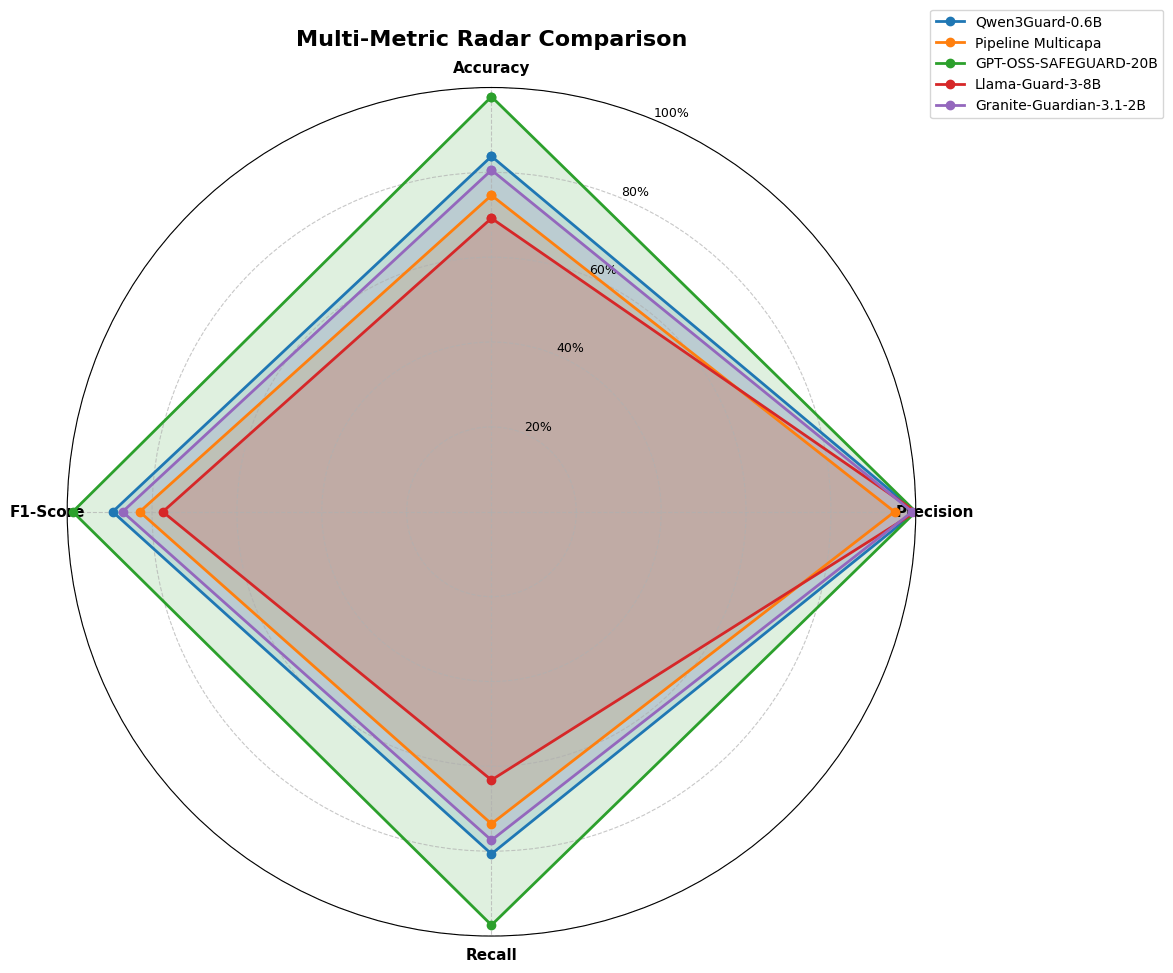

✅ Figure 6: Radar comparison saved to figures/radar_comparison.png


In [19]:
# 6. Radar Chart for Multi-Metric Comparison
if len(models) > 0:
    from math import pi
    
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))
    
    # Metrics to compare
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    num_vars = len(metric_names)
    
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # Complete the circle
    
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_names, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for idx, (model_name, df) in enumerate(models.items()):
        metrics = calculate_metrics(df)
        values = [
            metrics['accuracy'] * 100,
            metrics['precision'] * 100,
            metrics['recall'] * 100,
            metrics['f1'] * 100
        ]
        values += values[:1]  # Complete the circle
        
        ax.plot(angles, values, 'o-', linewidth=2, label=model_name, 
               color=colors_list[idx], markersize=6)
        ax.fill(angles, values, alpha=0.15, color=colors_list[idx])
    
    ax.set_title('Multi-Metric Radar Comparison', 
                fontsize=16, fontweight='bold', pad=30)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
    
    plt.tight_layout()
    plt.savefig('figures/radar_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Figure 6: Radar comparison saved to figures/radar_comparison.png")

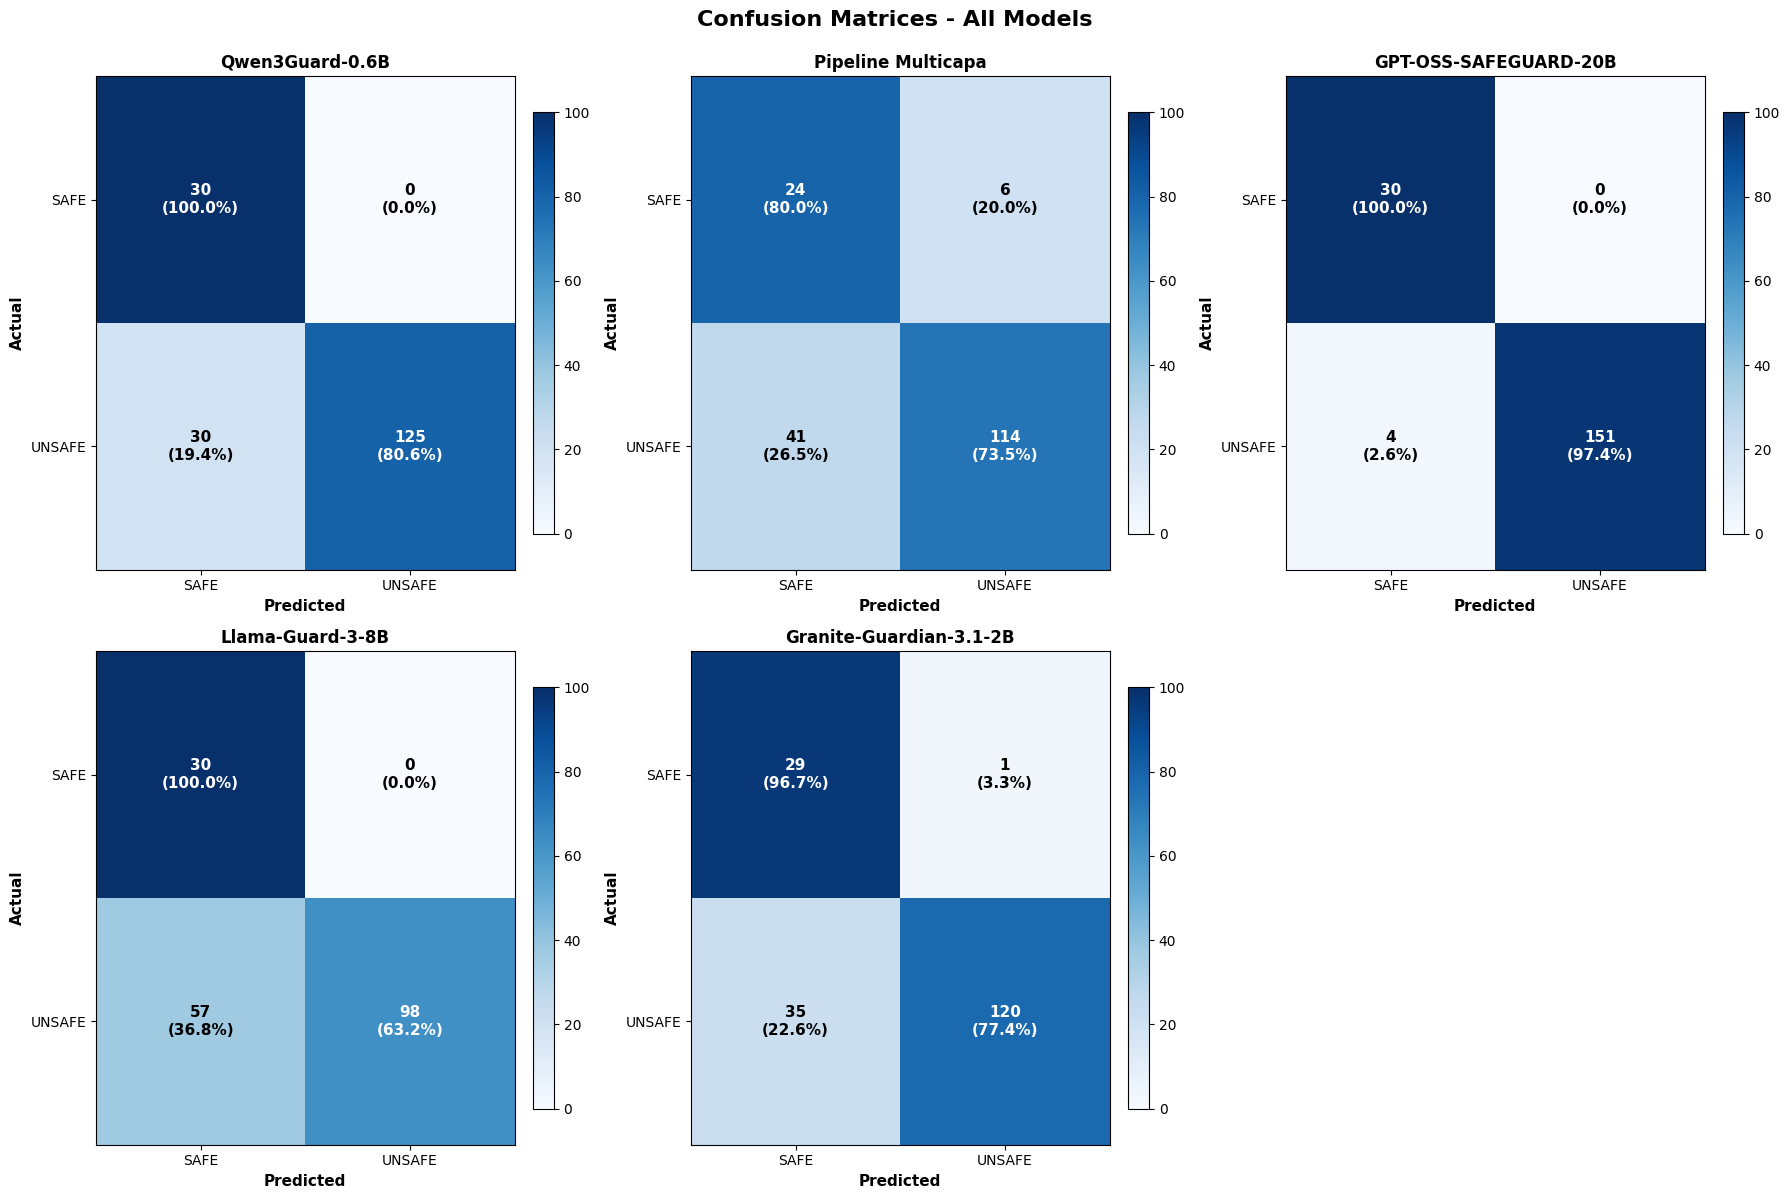

✅ Figure 4: Confusion matrices saved to figures/confusion_matrices.png


In [20]:
# 4. Confusion Matrices for All Models
if len(models) > 0:
    from sklearn.metrics import confusion_matrix
    
    n_models = len(models)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, (model_name, df) in enumerate(models.items()):
        # Map to binary
        y_true = (df['expected'] == 'UNSAFE').astype(int)
        y_pred = (df['predicted'] == 'UNSAFE').astype(int)
        
        cm = confusion_matrix(y_true, y_pred)
        
        # Normalize
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        
        ax = axes[idx]
        im = ax.imshow(cm_norm, cmap='Blues', aspect='auto', vmin=0, vmax=100)
        
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['SAFE', 'UNSAFE'], fontsize=10)
        ax.set_yticklabels(['SAFE', 'UNSAFE'], fontsize=10)
        ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
        ax.set_ylabel('Actual', fontsize=11, fontweight='bold')
        ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
        
        # Add text annotations
        for i in range(2):
            for j in range(2):
                text = ax.text(j, i, f'{cm[i, j]}\n({cm_norm[i, j]:.1f}%)',
                              ha="center", va="center", 
                              color="white" if cm_norm[i, j] > 50 else "black",
                              fontsize=11, fontweight='bold')
        
        # Colorbar
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    # Hide extra subplot
    if n_models < 6:
        for idx in range(n_models, 6):
            axes[idx].axis('off')
    
    plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig('figures/confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Figure 4: Confusion matrices saved to figures/confusion_matrices.png")

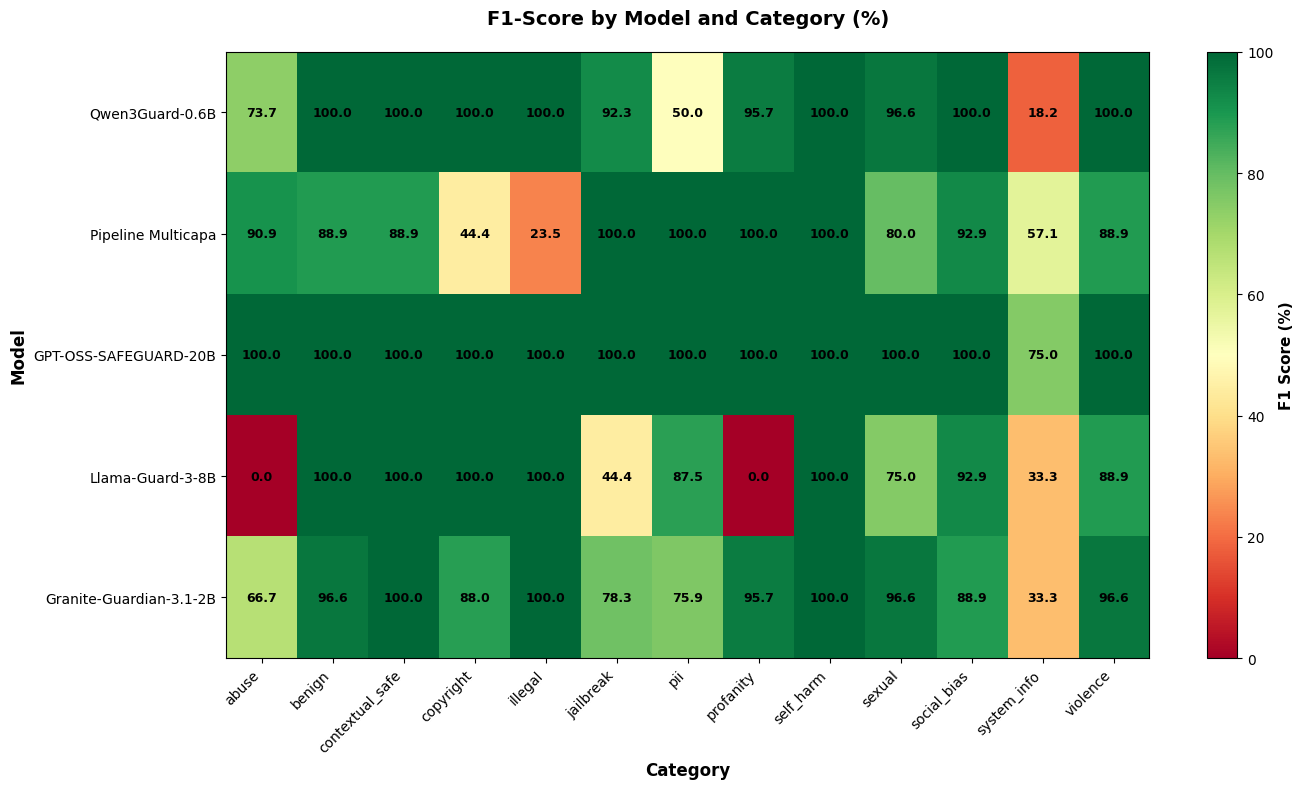

✅ Figure 3: Category heatmap saved to figures/category_heatmap.png


In [18]:
# 3. Category-Specific Performance Heatmap
if len(models) > 0:
    categories = sorted(list(models.values())[0]['category'].unique())
    model_names_clean = list(models.keys())
    
    # Categories where SAFE is the expected label
    SAFE_CATEGORIES = ['benign', 'contextual_safe']
    
    # Build matrix: models x categories
    perf_matrix = []
    
    for model_name in model_names_clean:
        df = models[model_name]
        row = []
        for category in categories:
            cat_df = df[df['category'] == category]
            if len(cat_df) > 0:
                # Use SAFE as positive label for benign/contextual_safe
                pos_label = 'SAFE' if category in SAFE_CATEGORIES else 'UNSAFE'
                metrics = calculate_metrics(cat_df, pos_label=pos_label)
                row.append(metrics['f1'] * 100)
            else:
                row.append(0)
        perf_matrix.append(row)
    
    perf_matrix = np.array(perf_matrix)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(perf_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
    
    # Set ticks
    ax.set_xticks(np.arange(len(categories)))
    ax.set_yticks(np.arange(len(model_names_clean)))
    ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(model_names_clean, fontsize=10)
    
    # Add text annotations
    for i in range(len(model_names_clean)):
        for j in range(len(categories)):
            text = ax.text(j, i, f'{perf_matrix[i, j]:.1f}',
                          ha="center", va="center", color="black", fontsize=9, fontweight='bold')
    
    ax.set_title('F1-Score by Model and Category (%)', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Category', fontsize=12, fontweight='bold')
    ax.set_ylabel('Model', fontsize=12, fontweight='bold')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('F1 Score (%)', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figures/category_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Figure 3: Category heatmap saved to figures/category_heatmap.png")

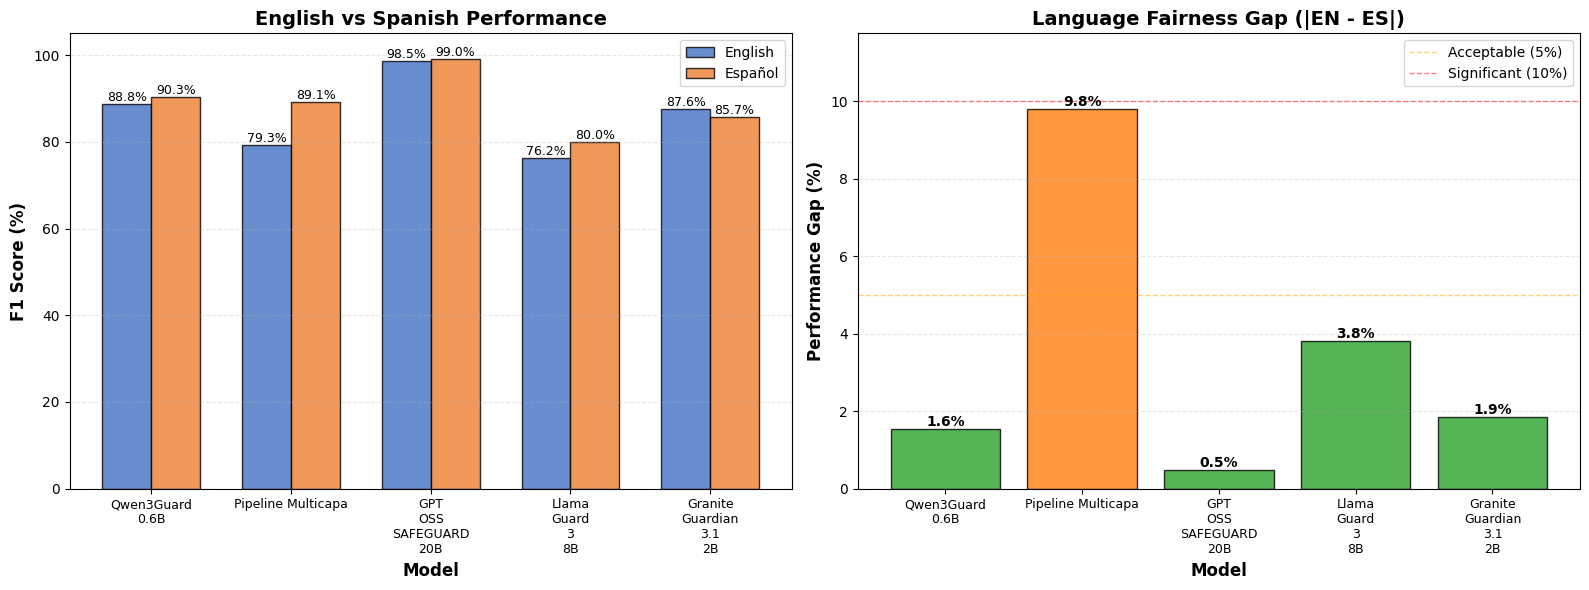

✅ Figure 2: Language fairness gap saved to figures/language_fairness_gap.png


In [8]:
# 2. Language Fairness Gap Visualization
if len(models) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    model_names = []
    en_f1 = []
    es_f1 = []
    gaps = []
    
    for model_name, df in models.items():
        if 'lang' in df.columns:
            lang_metrics = calculate_language_metrics(df, 'lang')
            if 'en' in lang_metrics and 'es' in lang_metrics:
                model_names.append(model_name.replace('-', '\n'))
                en_f1.append(lang_metrics['en']['f1'] * 100)
                es_f1.append(lang_metrics['es']['f1'] * 100)
                gaps.append(abs(lang_metrics['en']['f1'] - lang_metrics['es']['f1']) * 100)
    
    # Grouped bar chart for EN vs ES
    x = np.arange(len(model_names))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, en_f1, width, label='English', color='#4472C4', alpha=0.8, edgecolor='black')
    bars2 = ax1.bar(x + width/2, es_f1, width, label='Español', color='#ED7D31', alpha=0.8, edgecolor='black')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=9)
    
    ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax1.set_ylabel('F1 Score (%)', fontsize=12, fontweight='bold')
    ax1.set_title('English vs Spanish Performance', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_names, fontsize=9)
    ax1.legend()
    ax1.set_ylim(0, 105)
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Gap chart with color coding
    gap_colors = ['#2ca02c' if g < 5 else '#ff7f0e' if g < 10 else '#d62728' for g in gaps]
    bars_gap = ax2.bar(range(len(model_names)), gaps, color=gap_colors, alpha=0.8, edgecolor='black')
    
    for bar, gap in zip(bars_gap, gaps):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{gap:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Performance Gap (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Language Fairness Gap (|EN - ES|)', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(len(model_names)))
    ax2.set_xticklabels(model_names, fontsize=9)
    ax2.axhline(y=5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Acceptable (5%)')
    ax2.axhline(y=10, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Significant (10%)')
    ax2.legend()
    ax2.set_ylim(0, max(gaps) * 1.2 if gaps else 15)
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.savefig('figures/language_fairness_gap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Figure 2: Language fairness gap saved to figures/language_fairness_gap.png")

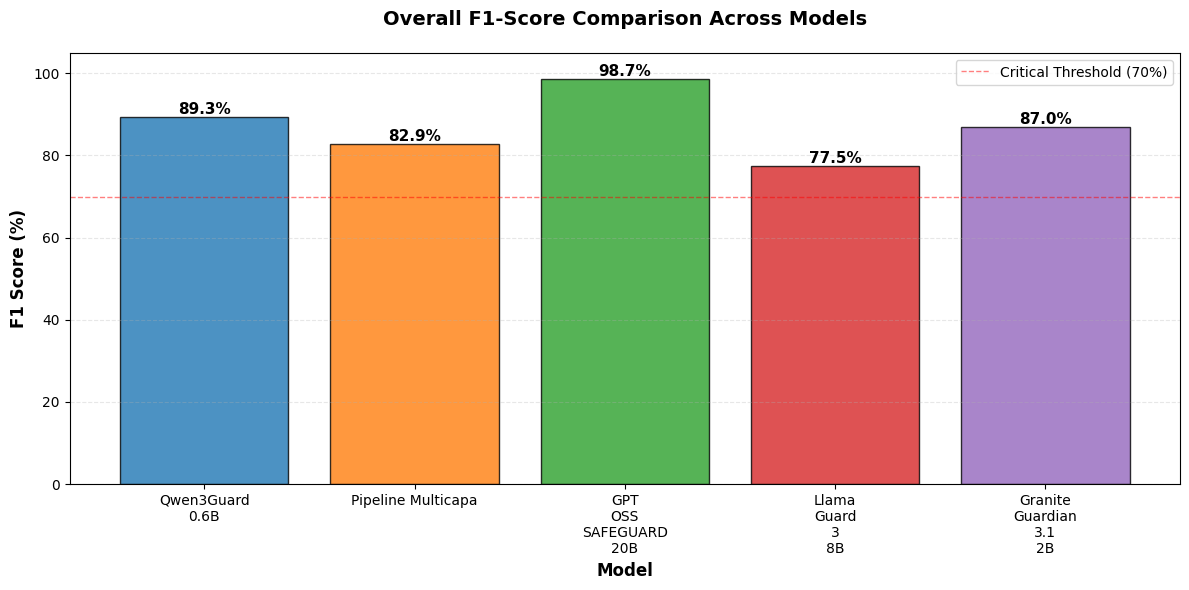

✅ Figure 1: Overall F1 comparison saved to figures/overall_f1_comparison.png


In [9]:
# 1. Overall F1 Score Comparison Bar Chart
if len(models) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    model_names = []
    f1_scores = []
    colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for model_name, df in models.items():
        metrics = calculate_metrics(df)
        model_names.append(model_name.replace('-', '\n'))  # Break long names
        f1_scores.append(metrics['f1'] * 100)
    
    bars = ax.bar(range(len(model_names)), f1_scores, color=colors_list[:len(model_names)], alpha=0.8, edgecolor='black')
    
    # Add value labels on bars
    for i, (bar, score) in enumerate(zip(bars, f1_scores)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{score:.1f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('F1 Score (%)', fontsize=12, fontweight='bold')
    ax.set_title('Overall F1-Score Comparison Across Models', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylim(0, 105)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.axhline(y=70, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Critical Threshold (70%)')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('figures/overall_f1_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Figure 1: Overall F1 comparison saved to figures/overall_f1_comparison.png")

## Visualizations

In [10]:
print("=" * 100)
print("LANGUAGE PERFORMANCE GAP ANALYSIS (English vs Español)")
print("=" * 100)

for model_name, df in models.items():
    if 'lang' in df.columns:
        lang_metrics = calculate_language_metrics(df, 'lang')
        
        if 'en' in lang_metrics and 'es' in lang_metrics:
            en_f1 = lang_metrics['en']['f1']
            es_f1 = lang_metrics['es']['f1']
            gap = abs(en_f1 - es_f1)
            
            print(f"\n{model_name}:")
            print(f"   English F1: {en_f1*100:.1f}%")
            print(f"   Español F1: {es_f1*100:.1f}%")
            print(f"   Gap: {gap*100:.1f}%", end=" ")
            
            if gap < 0.05:
                print("✅ Excellent (< 5%)")
            elif gap < 0.10:
                print("⚠️  Acceptable (< 10%)")
            else:
                print("❌ Significant (>= 10%)")
            
            if en_f1 > es_f1:
                print(f"   → English performs {(en_f1-es_f1)*100:.1f}% better")
            else:
                print(f"   → Español performs {(es_f1-en_f1)*100:.1f}% better")

print("\n" + "=" * 100)

LANGUAGE PERFORMANCE GAP ANALYSIS (English vs Español)

Qwen3Guard-0.6B:
   English F1: 88.8%
   Español F1: 90.3%
   Gap: 1.6% ✅ Excellent (< 5%)
   → Español performs 1.6% better

Pipeline Multicapa:
   English F1: 79.3%
   Español F1: 89.1%
   Gap: 9.8% ⚠️  Acceptable (< 10%)
   → Español performs 9.8% better

GPT-OSS-SAFEGUARD-20B:
   English F1: 98.5%
   Español F1: 99.0%
   Gap: 0.5% ✅ Excellent (< 5%)
   → Español performs 0.5% better

Llama-Guard-3-8B:
   English F1: 76.2%
   Español F1: 80.0%
   Gap: 3.8% ✅ Excellent (< 5%)
   → Español performs 3.8% better

Granite-Guardian-3.1-2B:
   English F1: 87.6%
   Español F1: 85.7%
   Gap: 1.9% ✅ Excellent (< 5%)
   → English performs 1.9% better



## Category-Specific Performance

In [15]:
# Identify best model per category
print("=" * 100)
print("BEST MODEL PER CATEGORY")
print("=" * 100)

categories = models[list(models.keys())[0]]['category'].unique()

# Categories where SAFE is the expected label
SAFE_CATEGORIES = ['benign', 'contextual_safe']

for category in sorted(categories):
    print(f"\n📁 {category.upper()}:")
    
    cat_results = []
    for model_name, df in models.items():
        cat_df = df[df['category'] == category]
        if len(cat_df) > 0:
            # Use SAFE as positive label for benign/contextual_safe
            pos_label = 'SAFE' if category in SAFE_CATEGORIES else 'UNSAFE'
            metrics = calculate_metrics(cat_df, pos_label=pos_label)
            cat_results.append({
                'model': model_name,
                'f1': metrics['f1'],
                'accuracy': metrics['accuracy']
            })
    
    # Sort by F1
    cat_results.sort(key=lambda x: x['f1'], reverse=True)
    
    for i, result in enumerate(cat_results[:3]):  # Top 3
        medal = ['🥇', '🥈', '🥉'][i]
        print(f"   {medal} {result['model']:30} F1: {result['f1']*100:5.1f}% | Acc: {result['accuracy']*100:5.1f}%")

print("\n" + "=" * 100)

BEST MODEL PER CATEGORY

📁 ABUSE:
   🥇 GPT-OSS-SAFEGUARD-20B          F1: 100.0% | Acc: 100.0%
   🥈 Pipeline Multicapa             F1:  90.9% | Acc:  83.3%
   🥉 Qwen3Guard-0.6B                F1:  73.7% | Acc:  58.3%

📁 BENIGN:
   🥇 Qwen3Guard-0.6B                F1: 100.0% | Acc: 100.0%
   🥈 GPT-OSS-SAFEGUARD-20B          F1: 100.0% | Acc: 100.0%
   🥉 Llama-Guard-3-8B               F1: 100.0% | Acc: 100.0%

📁 CONTEXTUAL_SAFE:
   🥇 Qwen3Guard-0.6B                F1: 100.0% | Acc: 100.0%
   🥈 GPT-OSS-SAFEGUARD-20B          F1: 100.0% | Acc: 100.0%
   🥉 Llama-Guard-3-8B               F1: 100.0% | Acc: 100.0%

📁 COPYRIGHT:
   🥇 Qwen3Guard-0.6B                F1: 100.0% | Acc: 100.0%
   🥈 GPT-OSS-SAFEGUARD-20B          F1: 100.0% | Acc: 100.0%
   🥉 Llama-Guard-3-8B               F1: 100.0% | Acc: 100.0%

📁 ILLEGAL:
   🥇 Qwen3Guard-0.6B                F1: 100.0% | Acc: 100.0%
   🥈 GPT-OSS-SAFEGUARD-20B          F1: 100.0% | Acc: 100.0%
   🥉 Llama-Guard-3-8B               F1: 100.0% | Acc: 1

## Critical Weaknesses Summary

In [16]:
print("=" * 100)
print("CRITICAL WEAKNESSES (F1 < 70% per category)")
print("=" * 100)

# Categories where SAFE is the expected label
SAFE_CATEGORIES = ['benign', 'contextual_safe']

for model_name, df in models.items():
    print(f"\n{model_name}:")
    
    weak_found = False
    for category in df['category'].unique():
        cat_df = df[df['category'] == category]
        # Use SAFE as positive label for benign/contextual_safe
        pos_label = 'SAFE' if category in SAFE_CATEGORIES else 'UNSAFE'
        metrics = calculate_metrics(cat_df, pos_label=pos_label)
        
        if metrics['f1'] < 0.7:
            weak_found = True
            print(f"   ❌ {category:15} F1: {metrics['f1']*100:5.1f}% - NOT RECOMMENDED")
    
    if not weak_found:
        print("   ✅ No critical weaknesses (all categories F1 >= 70%)")

print("\n" + "=" * 100)

CRITICAL WEAKNESSES (F1 < 70% per category)

Qwen3Guard-0.6B:
   ❌ pii             F1:  50.0% - NOT RECOMMENDED
   ❌ system_info     F1:  18.2% - NOT RECOMMENDED

Pipeline Multicapa:
   ❌ copyright       F1:  44.4% - NOT RECOMMENDED
   ❌ illegal         F1:  23.5% - NOT RECOMMENDED
   ❌ system_info     F1:  57.1% - NOT RECOMMENDED

GPT-OSS-SAFEGUARD-20B:
   ✅ No critical weaknesses (all categories F1 >= 70%)

Llama-Guard-3-8B:
   ❌ jailbreak       F1:  44.4% - NOT RECOMMENDED
   ❌ profanity       F1:   0.0% - NOT RECOMMENDED
   ❌ abuse           F1:   0.0% - NOT RECOMMENDED
   ❌ system_info     F1:  33.3% - NOT RECOMMENDED

Granite-Guardian-3.1-2B:
   ❌ abuse           F1:  66.7% - NOT RECOMMENDED
   ❌ system_info     F1:  33.3% - NOT RECOMMENDED



## Recommendations

In [17]:
print("=" * 100)
print("RECOMMENDATIONS")
print("=" * 100)

# Find best overall model
best_model = None
best_f1 = 0

for model_name, df in models.items():
    metrics = calculate_metrics(df)
    if metrics['f1'] > best_f1:
        best_f1 = metrics['f1']
        best_model = model_name

print(f"\n🏆 BEST OVERALL MODEL: {best_model}")
print(f"   F1 Score: {best_f1*100:.1f}%")

# Find best for LATAM
print(f"\n🌎 BEST FOR LATAM (Spanish performance):")
best_es = None
best_es_f1 = 0

for model_name, df in models.items():
    if 'lang' in df.columns:
        lang_metrics = calculate_language_metrics(df, 'lang')
        if 'es' in lang_metrics:
            es_f1 = lang_metrics['es']['f1']
            if es_f1 > best_es_f1:
                best_es_f1 = es_f1
                best_es = model_name

if best_es:
    print(f"   {best_es}")
    print(f"   Español F1: {best_es_f1*100:.1f}%")

# Cost/Performance recommendations
print(f"\n💰 COST-EFFECTIVE OPTIONS:")
print(f"   • Local (no API costs): Qwen3Guard-0.6B or Pipeline Multicapa")
print(f"   • Best API: Check GPT-OSS vs Llama-Guard vs Granite above")

print("\n" + "=" * 100)

RECOMMENDATIONS

🏆 BEST OVERALL MODEL: GPT-OSS-SAFEGUARD-20B
   F1 Score: 98.7%

🌎 BEST FOR LATAM (Spanish performance):
   GPT-OSS-SAFEGUARD-20B
   Español F1: 99.0%

💰 COST-EFFECTIVE OPTIONS:
   • Local (no API costs): Qwen3Guard-0.6B or Pipeline Multicapa
   • Best API: Check GPT-OSS vs Llama-Guard vs Granite above



## Export Comparison Report